## Automated Hyperparameter Selection 

This tutorial demonstrates how to automatically select optimal Gaussian Process hyperparameters for your surrogate model by testing multiple configurations and choosing the one with the best test set performance.

### Why This Matters

GP surrogate model performance is highly sensitive to:
- **Kernel choice** (ExpSquared, Matern32, Matern52, etc.)
- **Data scaling** (no scaling, MinMax, StandardScaler)
- **Other hyperparameters** (white noise, amplitude, length scales)

Rather than manually tuning these, we can systematically test combinations and select the best configuration based on test set mean squared error (MSE).

### Step 1: Import Required Libraries

Import `alabi` and its submodules along with standard scientific computing libraries.

In [10]:
import alabi
import alabi.utility as ut
import alabi.benchmarks as bm
from alabi.core import SurrogateModel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from itertools import product

from matplotlib import rcParams
# rcParams['font.family'] = 'serif'
# rcParams['text.usetex'] = True

random_state = 101
np.random.seed(random_state)

### Step 2: Define Problem and Base Configuration

Set up the benchmark problem (eggbox function) and define a base configuration for GP hyperparameters. These settings will be partially overridden when we test different combinations.

**Key parameters:**
- `ninit`: Number of initial training points
- `niter`: Number of active learning iterations
- `ncore`: Number of CPU cores for parallel evaluation (use 1 if experiencing multiprocessing issues)
- `white_noise`: Log-scale white noise parameter (increase if you see positive definiteness errors)

In [11]:
ninit = 50
niter = 100
basedir = "demo"
kernel = "ExpSquaredKernel"
benchmark = "rosenbrock"
savedir = f"{basedir}/{benchmark}/{kernel}/{ninit}_{niter}"

gp_kwargs = {"kernel": kernel, 
             "fit_amp": True, 
             "fit_mean": True, 
             "fit_white_noise": False, 
             "white_noise": -12,
             "gp_opt_method": "l-bfgs-b",
             "hyperopt_method": "cv",
             "cv_folds": 8,
             "gp_amp_rng": [-1,1],
             "gp_scale_rng": [-2,2],
             "theta_scaler": alabi.no_scaler,
             "y_scaler": alabi.no_scaler}
    
sm = SurrogateModel(lnlike_fn=bm.eggbox["fn"], 
                    bounds=bm.eggbox["bounds"], 
                    savedir=savedir,
                    ncore=8, 
                    pool_method="forkserver",
                    verbose=True,
                    random_state=random_state)

sm.init_samples(ntrain=ninit, ntest=1000, sampler="lhs")

100%|██████████| 1000/1000 [00:01<00:00, 883.55it/s]


### Step 3: Create Hyperparameter Grid

Generate all combinations of the hyperparameters we want to test:
- **Kernels**: Different covariance functions capture different smoothness assumptions
- **Theta scaler**: How to scale input parameters
- **Y scaler**: How to scale output values

The `dict_to_combinations` function creates a Cartesian product of all options.

In [12]:
def dict_to_combinations(options_dict):
    keys = options_dict.keys()
    values = options_dict.values()
    return [dict(zip(keys, combo)) for combo in product(*values)]

def combinations_to_dict(combinations):
    result = {key: [] for key in combinations[0].keys()}
    for combo in combinations:
        for key, value in combo.items():
            result[key].append(value)
    return result

gp_kwarg_options = {"kernel": ["ExpSquaredKernel", "Matern32Kernel", "Matern52Kernel"],
                    "theta_scaler": [ut.no_scaler, preprocessing.MinMaxScaler(), preprocessing.StandardScaler()],
                    "y_scaler": [ut.no_scaler, preprocessing.MinMaxScaler(), preprocessing.StandardScaler()]}

variable_settings = dict_to_combinations(gp_kwarg_options)
print(len(variable_settings), "combinations to test")

# get a list of dictionaries with all combinations of settings, where each dictionary is a copy of the original gp_kwargs with the variable settings updated
setting_combos = []
for settings in variable_settings:
    new_settings = gp_kwargs.copy()
    for key in settings.keys():
        new_settings[key] = settings[key]
    setting_combos.append(new_settings)

27 combinations to test


### Step 4: Test All Hyperparameter Combinations

Loop through all combinations and fit a GP for each. The `init_gp` method returns the test set MSE, which we use to evaluate performance.

**Note:** This can take several minutes depending on the number of combinations and problem dimensionality. Use `try/except` to handle configurations that fail to converge.

In [ ]:
# docs: collapse output
for ii in range(len(setting_combos)):
    try:
        test_mse = sm.init_gp(**setting_combos[ii], overwrite=True)
    except:
        test_mse = np.nan
    setting_combos[ii]["test_mse"] = test_mse

### Step 5: Analyze Results

Convert results to a pandas DataFrame and inspect the top-performing configurations. Lower test MSE indicates better generalization performance.

In [14]:
results = pd.DataFrame(data=combinations_to_dict(setting_combos))
top_fits = results.sort_values("test_mse").head(5)
top_fits

,kernel,fit_amp,fit_mean,fit_white_noise,white_noise,gp_opt_method,hyperopt_method,cv_folds,gp_amp_rng,gp_scale_rng,theta_scaler,y_scaler,test_mse
7,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),MinMaxScaler(),1993.447717
8,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),StandardScaler(),1998.471961
24,Matern52Kernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),no_scaler,2029.055811
6,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),no_scaler,2066.363090
11,Matern32Kernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",no_scaler,StandardScaler(),2067.461220


### Step 6: Extract Best Configuration

Identify the hyperparameter configuration with the lowest test MSE. This will be used for active learning.

In [15]:
best_gp_results = results[results["test_mse"] == results["test_mse"].min()]
best_gp_results

,kernel,fit_amp,fit_mean,fit_white_noise,white_noise,gp_opt_method,hyperopt_method,cv_folds,gp_amp_rng,gp_scale_rng,theta_scaler,y_scaler,test_mse
7,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),MinMaxScaler(),1993.447717


### Step 7: Run Active Learning

Use the optimal GP configuration for active learning. The BAPE (Bayesian Active Posterior Estimation) algorithm iteratively selects new training points to improve the surrogate model.

**Key active learning parameters:**
- `algorithm`: Acquisition function ("bape", "agp", or "jones")
- `gp_opt_freq`: How often to reoptimize GP hyperparameters during training
- `obj_opt_method`: Optimization method for acquisition function
- `nopt`: Number of optimization restarts for acquisition function

In [ ]:
# docs: collapse output
best_gp_kwargs = best_gp_results[gp_kwargs.keys()].to_dict(orient="records")[0]

al_kwargs = {"algorithm": "bape", 
             "gp_opt_freq": 20, 
             "obj_opt_method": "nelder-mead", 
             "nopt": 6}

sm.init_gp(**best_gp_kwargs, overwrite=True)
sm.active_train(niter=200, **al_kwargs)

### Step 8: Visualize Training Progress

Plot the test set MSE over active learning iterations. A decreasing trend indicates the surrogate model is improving. We can also highlight which iterations the GP hyperparameters are re-optimized (vertical gray lines).

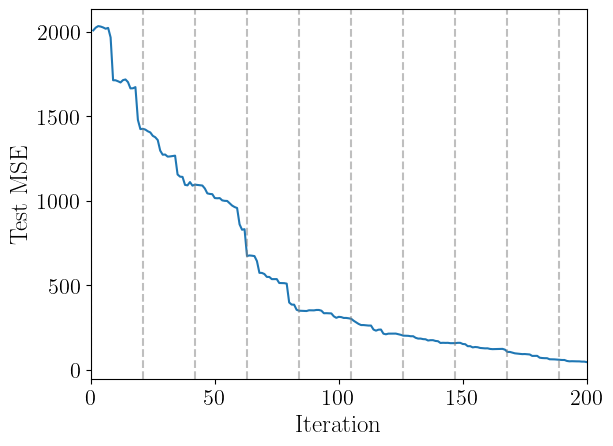

In [17]:
plt.plot(sm.training_results["iteration"], sm.training_results["test_mse"])
for ii in range(0, sm.nactive, sm.gp_opt_freq+1):
    plt.axvline(ii, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Iteration", fontsize=18)
plt.ylabel("Test MSE", fontsize=18)
plt.xlim(0, sm.nactive)
plt.show()

How much does random variance affect the performance?

Let's do a trial where we do 10 attempts with the same hyperparameter configuration and track the test mse:

In [ ]:
# docs: collapse output
best_gp_kwargs = best_gp_results[gp_kwargs.keys()].to_dict(orient="records")[0]

test_mse_trials = []
for ii in range(10):
    al_kwargs = {"algorithm": "bape", 
                "gp_opt_freq": 20, 
                "obj_opt_method": "nelder-mead", 
                "nopt": 6}

    sm.init_gp(**best_gp_kwargs, overwrite=True)
    sm.active_train(niter=200, **al_kwargs)
    test_mse_trials.append(sm.training_results["test_mse"])

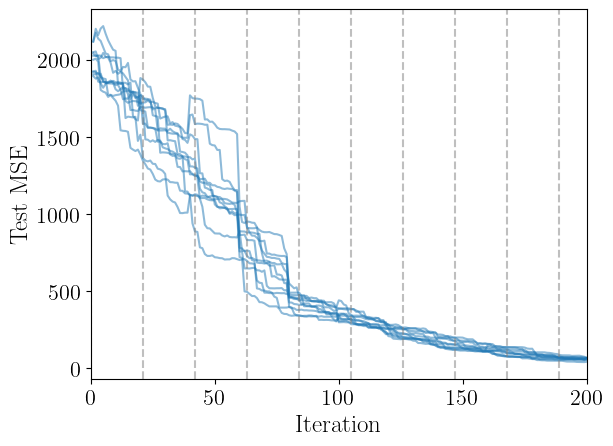

In [26]:
for test_mse in test_mse_trials:
    plt.plot(sm.training_results["iteration"], test_mse, color="C0", alpha=0.5)
for ii in range(0, sm.nactive, sm.gp_opt_freq+1):
    plt.axvline(ii, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Iteration", fontsize=18)
plt.ylabel("Test MSE", fontsize=18)
plt.xlim(0, sm.nactive)
plt.show()

How do the other top initial fits perform during active learning?

In [ ]:
# docs: collapse output
al_kwargs = {"algorithm": "bape", 
             "gp_opt_freq": 20, 
             "obj_opt_method": "nelder-mead", 
             "nopt": 6}

mse_results = {}
for idx in top_fits.index:
    gp_kwargs_idx = top_fits[top_fits.index == idx][gp_kwargs.keys()].to_dict(orient="records")[0]
    sm.init_gp(**gp_kwargs_idx, overwrite=True)
    sm.active_train(niter=200, **al_kwargs)
    mse_results[idx] = sm.training_results["test_mse"]

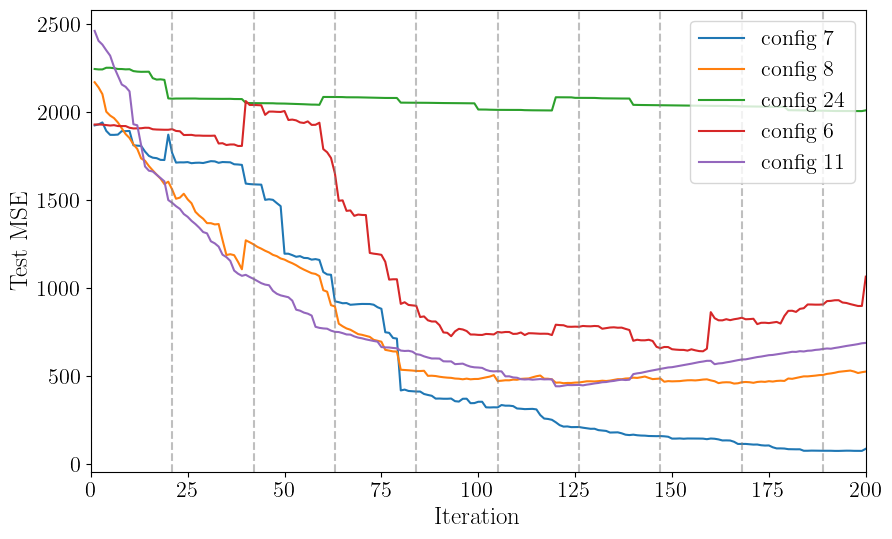

,kernel,fit_amp,fit_mean,fit_white_noise,white_noise,gp_opt_method,hyperopt_method,cv_folds,gp_amp_rng,gp_scale_rng,theta_scaler,y_scaler,test_mse
7,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),MinMaxScaler(),1993.447717
8,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),StandardScaler(),1998.471961
24,Matern52Kernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),no_scaler,2029.055811
6,ExpSquaredKernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",StandardScaler(),no_scaler,2066.363090
11,Matern32Kernel,True,True,False,-12,l-bfgs-b,cv,8,"[-1, 1]","[-2, 2]",no_scaler,StandardScaler(),2067.461220


In [24]:
plt.figure(figsize=(10,6))
for idx in top_fits.index:
    plt.plot(sm.training_results["iteration"], mse_results[idx], label=f"config {idx}")
for ii in range(0, sm.nactive, sm.gp_opt_freq+1):
    plt.axvline(ii, color="gray", linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=16)
plt.xlabel("Iteration", fontsize=18)
plt.ylabel("Test MSE", fontsize=18)
plt.xlim(0, sm.nactive)
plt.show()

top_fits

Here we see that the configuration for best initial fit isn't always necessarily the best fit after running active learning, but it is not a bad place to start. In practice, if the test error is not converging, it may be an indication to try a different configuration of hyperparameters.

### Next Steps

Now that you have an optimized surrogate model, you can:

1. **Run posterior sampling** with `sm.run_emcee()` or `sm.run_dynesty()`
2. **Visualize the surrogate** using `alabi.visualization` tools
3. **Test on new problems** by changing the benchmark function
4. **Expand the hyperparameter grid** to include more options like:
   - Different `white_noise` values
   - Different `cv_folds` settings
   - Different data scaling functions for `theta_scaler` or `y_scaler`